s2_supres

In [9]:
from __future__ import division
import argparse
import numpy as np
import os
import re
import sys
from osgeo import gdal, osr
from collections import defaultdict
from supres import DSen2_20, DSen2_60

# This code is adapted from this repository http://nicolas.brodu.net/code/superres and is distributed under the same
# license.

parser = argparse.ArgumentParser(description="Perform super-resolution on Sentinel-2 with DSen2. Code based on superres"
                                             " by Nicolas Brodu.",
                                 formatter_class=argparse.ArgumentDefaultsHelpFormatter)
parser.add_argument("data_file",
                    help="An input sentinel-2 data file. This can be either the original ZIP file, or the S2A[...].xml "
                         "file in a SAFE directory extracted from that ZIP.")
parser.add_argument("output_file", nargs="?",
                    help="A target data file. See also the --save_prefix option, and the --output_file_format option "
                         "(default is GTiff).")
parser.add_argument("--roi_lon_lat", default="",
                    help="Sets the region of interest to extract, WGS84, decimal notation. Use this syntax: lon_1,"
                         "lat_1,lon_2,lat_2. The order of points 1 and 2 does not matter: the region of interest "
                         "extends to the min/max in each direction. "
                         "Example: --roi_lon_lat=-1.12132,44.72408,-0.90350,44.58646")
parser.add_argument("--roi_x_y", default="",
                    help="Sets the region of interest to extract as pixels locations on the 10m bands. Use this "
                         "syntax: x_1,y_1,x_2,y_2. The order of points 1 and 2 does not matter: the region of interest "
                         "extends to the min/max in each direction and to nearby 60m pixel boundaries.")
parser.add_argument("--list_bands", action="store_true",
                    help="List bands in the input file subdata set matching the selected UTM zone, and exit.")
parser.add_argument("--run_60", action="store_true",
                    help="Select which bands to process and include in the output file. If this flag is set it will "
                         "super-resolve the 20m and 60m bands (B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12). If it is not "
                         "set it will only super-resolve the 20m bands (B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12). Band B10 "
                         "is to noisy and is not super-resolved.")
parser.add_argument("--list_UTM", action="store_true",
                    help="List all UTM zones present in the input file, together with their coverage of the ROI in "
                         "10m x 10m pixels.")
parser.add_argument("--select_UTM", default="",
                    help="Select a UTM zone. The default is to select the zone with the largest coverage of the ROI.")
parser.add_argument("--list_output_file_formats", action="store_true",
                    help="If specified, list all supported raster output file formats declared by GDAL and exit. Some "
                         "of these formats may be inappropriate for storing Sentinel-2 multispectral data.")
parser.add_argument("--output_file_format", default="GTiff",
                    help="Speficies the name of a GDAL driver that supports file creation, like ENVI or GTiff. If no "
                         "such driver exists, or if the format is \"npz\", then save all bands instead as a compressed "
                         "python/numpy file")
parser.add_argument("--copy_original_bands", action="store_true",
                    help="The default is not to copy the original selected 10m bands into the output file in addition "
                         "to the super-resolved bands. If this flag is used, the output file may be used as a 10m "
                         "version of the original Sentinel-2 file.")
parser.add_argument("--save_prefix", default="",
                    help="If set, speficies the name of a prefix for all output files. Use a trailing / to save into a "
                         "directory. The default of no prefix will save into the current directory. "
                         "Example: --save_prefix result/")


args = parser.parse_args()
globals().update(args.__dict__)
data_file="/home/liuzirong/code/SR_ISS/data/S2A_MSIL1C_20170527_T33UUB.mat"
if list_output_file_formats:
    dcount = gdal.GetDriverCount()
    for didx in range(dcount):
        driver = gdal.GetDriver(didx)
        if driver:
            metadata = driver.GetMetadata()
        if (gdal.DCAP_CREATE in (driver and metadata) and metadata[gdal.DCAP_CREATE] == 'YES' and
        gdal.DCAP_RASTER in metadata and metadata[gdal.DCAP_RASTER] == 'YES'):
            name = driver.GetDescription()
            if "DMD_LONGNAME" in metadata:
                name += ": " + metadata["DMD_LONGNAME"]
            else:
                name = driver.GetDescription()
            if "DMD_EXTENSIONS" in metadata: name += " (" + metadata["DMD_EXTENSIONS"] + ")"
            print(name)
    sys.exit(0)

if run_60:
    select_bands = 'B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B11,B12'
else:
    select_bands = 'B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12'

# convert comma separated band list into a list
select_bands = [x for x in re.split(',', select_bands)]

if roi_lon_lat:
    roi_lon1, roi_lat1, roi_lon2, roi_lat2 = [float(x) for x in re.split(',', roi_lon_lat)]
else:
    roi_lon1, roi_lat1, roi_lon2, roi_lat2 = -180, -90, 180, 90

if roi_x_y:
    roi_x1, roi_y1, roi_x2, roi_y2 = [float(x) for x in re.split(',', roi_x_y)]

raster = gdal.Open(data_file)


datasets = raster.GetSubDatasets();
tenMsets = []
twentyMsets = []
sixtyMsets = []
unknownMsets = []
for (dsname, dsdesc) in datasets:
    if '10m resolution' in dsdesc:
        tenMsets += [(dsname, dsdesc)]
    elif '20m resolution' in dsdesc:
        twentyMsets += [(dsname, dsdesc)]
    elif '60m resolution' in dsdesc:
        sixtyMsets += [(dsname, dsdesc)]
    else:
        unknownMsets += [(dsname, dsdesc)]

# case where we have several UTM in the data set
# => select the one with maximal coverage of the study zone
utm_idx = 0
utm = select_UTM
all_utms = defaultdict(int)
xmin, ymin, xmax, ymax = 0, 0, 0, 0
largest_area = -1
# process even if there is only one 10m set, in order to get roi -> pixels
for (tmidx, (dsname, dsdesc)) in enumerate(tenMsets + unknownMsets):
    ds = gdal.Open(dsname)
    if roi_x_y:
        tmxmin = max(min(roi_x1, roi_x2, ds.RasterXSize - 1), 0)
        tmxmax = min(max(roi_x1, roi_x2, 0), ds.RasterXSize - 1)
        tmymin = max(min(roi_y1, roi_y2, ds.RasterYSize - 1), 0)
        tmymax = min(max(roi_y1, roi_y2, 0), ds.RasterYSize - 1)
        # enlarge to the nearest 60 pixel boundary for the super-resolution
        tmxmin = int(tmxmin / 6) * 6
        tmxmax = int((tmxmax + 1) / 6) * 6 - 1
        tmymin = int(tmymin / 6) * 6
        tmymax = int((tmymax + 1) / 6) * 6 - 1
    elif not roi_lon_lat:
        tmxmin = 0
        tmxmax = ds.RasterXSize - 1
        tmymin = 0
        tmymax = ds.RasterYSize - 1
    else:
        xoff, a, b, yoff, d, e = ds.GetGeoTransform()
        srs = osr.SpatialReference()
        srs.ImportFromWkt(ds.GetProjection())
        srsLatLon = osr.SpatialReference()
        srsLatLon.SetWellKnownGeogCS("WGS84");
        ct = osr.CoordinateTransformation(srsLatLon, srs)


        def to_xy(lon, lat):
            (xp, yp, h) = ct.TransformPoint(lon, lat, 0.)
            xp -= xoff
            yp -= yoff
            # matrix inversion
            det_inv = 1. / (a * e - d * b)
            x = (e * xp - b * yp) * det_inv
            y = (-d * xp + a * yp) * det_inv
            return (int(x), int(y))


        x1, y1 = to_xy(roi_lon1, roi_lat1)
        x2, y2 = to_xy(roi_lon2, roi_lat2)
        tmxmin = max(min(x1, x2, ds.RasterXSize - 1), 0)
        tmxmax = min(max(x1, x2, 0), ds.RasterXSize - 1)
        tmymin = max(min(y1, y2, ds.RasterYSize - 1), 0)
        tmymax = min(max(y1, y2, 0), ds.RasterYSize - 1)
        # enlarge to the nearest 60 pixel boundary for the super-resolution
        tmxmin = int(tmxmin / 6) * 6
        tmxmax = int((tmxmax + 1) / 6) * 6 - 1
        tmymin = int(tmymin / 6) * 6
        tmymax = int((tmymax + 1) / 6) * 6 - 1
    area = (tmxmax - tmxmin + 1) * (tmymax - tmymin + 1)
    current_utm = dsdesc[dsdesc.find("UTM"):]
    if area > all_utms[current_utm]:
        all_utms[current_utm] = area
    if current_utm == select_UTM:
        xmin, ymin, xmax, ymax = tmxmin, tmymin, tmxmax, tmymax
        utm_idx = tmidx
        utm = current_utm
        break
    if area > largest_area:
        xmin, ymin, xmax, ymax = tmxmin, tmymin, tmxmax, tmymax
        largest_area = area
        utm_idx = tmidx
        utm = dsdesc[dsdesc.find("UTM"):]

if list_UTM:
    print("List of UTM zones (with ROI coverage in pixels):")
    for u in all_utms:
        print("%s (%d)" % (u, all_utms[u]))
    sys.exit(0)

print("Selected UTM Zone:", utm)
print("Selected pixel region: xmin=%d, ymin=%d, xmax=%d, ymax=%d:" % (xmin, ymin, xmax, ymax))
print("Image size: width=%d x height=%d" % (xmax - xmin + 1, ymax - ymin + 1))

if xmax < xmin or ymax < ymin:
    print("Invalid region of interest / UTM Zone combination")
    sys.exit(0)

selected_10m_data_set = None
if not tenMsets:
    selected_10m_data_set = unknownMsets[0]
else:
    selected_10m_data_set = tenMsets[utm_idx]
selected_20m_data_set = None
for (dsname, dsdesc) in enumerate(twentyMsets):
    if utm in dsdesc:
        selected_20m_data_set = (dsname, dsdesc)
# if not found, assume the listing is in the same order
# => OK if only one set
if not selected_20m_data_set: selected_20m_data_set = twentyMsets[utm_idx]
selected_60m_data_set = None
for (dsname, dsdesc) in enumerate(sixtyMsets):
    if utm in dsdesc:
        selected_60m_data_set = (dsname, dsdesc)
if not selected_60m_data_set: selected_60m_data_set = sixtyMsets[utm_idx]

ds10 = gdal.Open(selected_10m_data_set[0])
ds20 = gdal.Open(selected_20m_data_set[0])
ds60 = gdal.Open(selected_60m_data_set[0])


def validate_description(description):
    m = re.match("(.*?), central wavelength (\d+) nm", description)
    if m:
        return m.group(1) + " (" + m.group(2) + " nm)"
    # Some HDR restrictions... ENVI band names should not include commas
    if output_file_format == 'ENVI' and ',' in description:
        pos = description.find(',')
        return description[:pos] + description[(pos + 1):]
    return description


if list_bands:
    print("\n10m bands:")
    for b in range(0, ds10.RasterCount):
        print("- " + validate_description(ds10.GetRasterBand(b + 1).GetDescription()))
    print("\n20m bands:")
    for b in range(0, ds20.RasterCount):
        print("- " + validate_description(ds20.GetRasterBand(b + 1).GetDescription()))
    print("\n60m bands:")
    for b in range(0, ds60.RasterCount):
        print("- " + validate_description(ds60.GetRasterBand(b + 1).GetDescription()))
    print("")


def get_band_short_name(description):
    if ',' in description:
        return description[:description.find(',')]
    if ' ' in description:
        return description[:description.find(' ')]
    return description[:3]


validated_10m_bands = []
validated_10m_indices = []
validated_20m_bands = []
validated_20m_indices = []
validated_60m_bands = []
validated_60m_indices = []
validated_descriptions = defaultdict(str)

sys.stdout.write("Selected 10m bands:")
for b in range(0, ds10.RasterCount):
    desc = validate_description(ds10.GetRasterBand(b + 1).GetDescription())
    shortname = get_band_short_name(desc)
    if shortname in select_bands:
        sys.stdout.write(" " + shortname)
        select_bands.remove(shortname)
        validated_10m_bands += [shortname]
        validated_10m_indices += [b]
        validated_descriptions[shortname] = desc
sys.stdout.write("\nSelected 20m bands:")
for b in range(0, ds20.RasterCount):
    desc = validate_description(ds20.GetRasterBand(b + 1).GetDescription())
    shortname = get_band_short_name(desc)
    if shortname in select_bands:
        sys.stdout.write(" " + shortname)
        select_bands.remove(shortname)
        validated_20m_bands += [shortname]
        validated_20m_indices += [b]
        validated_descriptions[shortname] = desc
sys.stdout.write("\nSelected 60m bands:")
for b in range(0, ds60.RasterCount):
    desc = validate_description(ds60.GetRasterBand(b + 1).GetDescription())
    shortname = get_band_short_name(desc)
    if shortname in select_bands:
        sys.stdout.write(" " + shortname)
        select_bands.remove(shortname)
        validated_60m_bands += [shortname]
        validated_60m_indices += [b]
        validated_descriptions[shortname] = desc
sys.stdout.write("\n")

if list_bands:
    sys.exit(0)

# All query options are processed, we now require an output file
if not output_file:
    print("Error: you must provide the name of an output file. I will set it identical to the input...")
    output_file = os.path.split(data_file)[1] + '.tif'
    # sys.exit(1)


output_file = save_prefix + output_file
# Some HDR restrictions... ENVI file name should be the .bin, not the .hdr
if output_file_format == 'ENVI' and (output_file[-4:] == '.hdr' or output_file[-4:] == '.HDR'):
    output_file = output_file[:-4] + '.bin'


if validated_10m_indices:
    print("Loading selected data from: %s" % selected_10m_data_set[1])
    data10 = np.rollaxis(
        ds10.ReadAsArray(xoff=xmin, yoff=ymin, xsize=xmax - xmin + 1, ysize=ymax - ymin + 1, buf_xsize=xmax - xmin + 1,
                         buf_ysize=ymax - ymin + 1), 0, 3)[:, :, validated_10m_indices]

if validated_20m_indices:
    print("Loading selected data from: %s" % selected_20m_data_set[1])
    data20 = np.rollaxis(
        ds20.ReadAsArray(xoff=xmin // 2, yoff=ymin // 2, xsize=(xmax - xmin + 1) // 2, ysize=(ymax - ymin + 1) // 2,
                         buf_xsize=(xmax - xmin + 1) // 2, buf_ysize=(ymax - ymin + 1) // 2), 0, 3)[:, :,
             validated_20m_indices]

if validated_60m_indices:
    print("Loading selected data from: %s" % selected_60m_data_set[1])
    data60 = np.rollaxis(
        ds60.ReadAsArray(xoff=xmin // 6, yoff=ymin // 6, xsize=(xmax - xmin + 1) // 6, ysize=(ymax - ymin + 1) // 6,
                         buf_xsize=(xmax - xmin + 1) // 6, buf_ysize=(ymax - ymin + 1) // 6), 0, 3)[:, :,
             validated_60m_indices]


if validated_60m_bands and validated_20m_bands and validated_10m_bands:
    print("Super-resolving the 60m data into 10m bands")
    sr60 = DSen2_60(data10, data20, data60, deep=False)
else:
    sr60 = None

if validated_10m_bands and validated_20m_bands:
    print("Super-resolving the 20m data into 10m bands")
    sr20 = DSen2_20(data10, data20, deep=False)
else:
    sr20 = None

sr_band_names = []

if sr20 is None:
    print("No super-resolution performed, exiting")
    sys.exit(0)

if output_file_format != "npz":
    revert_to_npz = True
    driver = gdal.GetDriverByName(output_file_format)
    if driver:
        metadata = driver.GetMetadata()
        if gdal.DCAP_CREATE in metadata and metadata[gdal.DCAP_CREATE] == 'YES':
            revert_to_npz = False
    if revert_to_npz:
        print("Gdal doesn't support creating %s files" % output_file_format)
        print("Writing to npz as a fallback")
        output_file_format = "npz"
    bands = None
else:
    bands = dict()
    result_dataset = None

bidx = 0
all_descriptions = []
source_band = dict()


def write_band_data(data, description, shortname=None):
    global all_descriptions
    global bidx
    all_descriptions += [description]
    if output_file_format == "npz":
        bands[description] = data
    else:
        bidx += 1
        result_dataset.GetRasterBand(bidx).SetDescription(description)
        result_dataset.GetRasterBand(bidx).WriteArray(data)


if sr60 is not None:
    sr = np.concatenate((sr20, sr60), axis=2)
    validated_sr_bands = validated_20m_bands + validated_60m_bands
else:
    sr = sr20
    validated_sr_bands = validated_20m_bands

if copy_original_bands:
    out_dims = data10.shape[2] + sr.shape[2]
else:
    out_dims = sr.shape[2]


sys.stdout.write("Writing")
result_dataset = driver.Create(output_file, data10.shape[1], data10.shape[0], out_dims, gdal.GDT_Float64)

# Translate the image upper left corner. We multiply x10 to transform from pixel position in the 10m_band to meters.
geot = list(ds10.GetGeoTransform())
geot[0] += xmin * 10
geot[3] -= ymin * 10
result_dataset.SetGeoTransform(tuple(geot))
result_dataset.SetProjection(ds10.GetProjection())

if copy_original_bands:
    sys.stdout.write(" the original 10m bands and")
    # Write the original 10m bands
    for bi, bn in enumerate(validated_10m_bands):
        write_band_data(data10[:, :, bi], validated_descriptions[bn])
print(" the super-resolved bands in %s" % output_file)
for bi, bn in enumerate(validated_sr_bands):
    write_band_data(sr[:, :, bi], "SR" + validated_descriptions[bn], "SR" + bn)


for desc in all_descriptions:
    print(desc)

if output_file_format == "npz":
    np.savez(output_file, bands=bands)



usage: ipykernel_launcher.py [-h] [--roi_lon_lat ROI_LON_LAT]
                             [--roi_x_y ROI_X_Y] [--list_bands] [--run_60]
                             [--list_UTM] [--select_UTM SELECT_UTM]
                             [--list_output_file_formats]
                             [--output_file_format OUTPUT_FILE_FORMAT]
                             [--copy_original_bands]
                             [--save_prefix SAVE_PREFIX]
                             data_file [output_file]
ipykernel_launcher.py: error: the following arguments are required: data_file


SystemExit: 2

/home/liuzirong/.conda/envs/py37/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3465: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


demoDSen2

Siberia
8 4
(616, 616, 4) 5 5 36
(36, 6, 128, 128)
(36, 6, 64, 64)
(36, 4, 128, 128)
[  0  56 112 168 224 244]
[  0  56 112 168 224 244]
count= 36


2023-04-06 23:28:51.670337: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-06 23:28:51.671159: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


Symbolic Model Created.
Predicting using file: ../models/s2_032_lr_1e-04.hdf5
2/2 [==============================] - 4s 411ms/step
(6, 600, 600)
DSen2:
RMSE: 31.2404
Bicubic:
RMSE: 157.6857


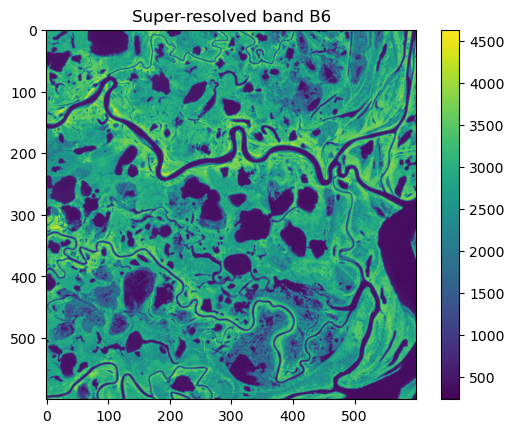

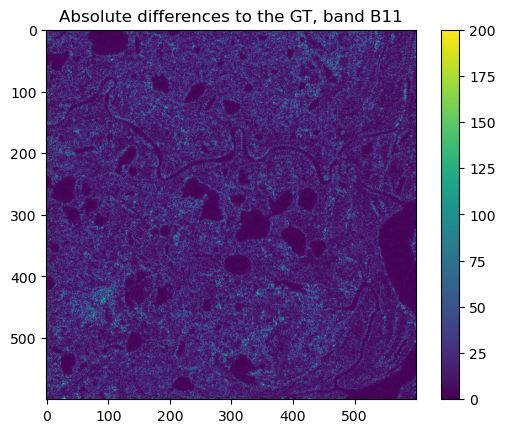

S. Africa
Symbolic Model Created.
Predicting using file: ../models/s2_030_lr_1e-05.hdf5
1/1 [==============================] - 3s 3s/step
(2, 600, 600)
DSen2:
RMSE: 20.4089
Bicubic:
RMSE: 129.1604


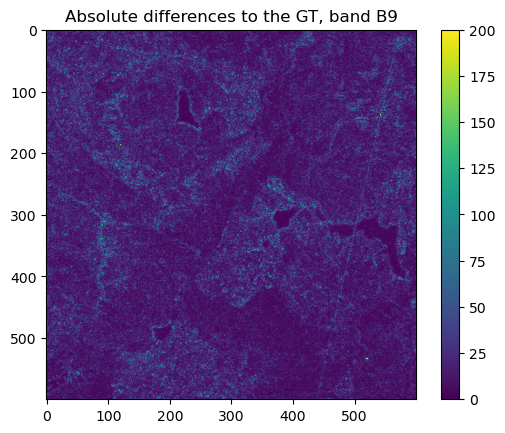

New York
8 4
(616, 616, 4) 5 5 36
(36, 6, 128, 128)
(36, 6, 64, 64)
(36, 4, 128, 128)
[  0  56 112 168 224 244]
[  0  56 112 168 224 244]
count= 36
Symbolic Model Created.
Predicting using file: ../models/s2_032_lr_1e-04.hdf5
2/2 [==============================] - 3s 411ms/step
(6, 600, 600)
DSen2:
RMSE: 64.2276
Bicubic:
RMSE: 213.5328
Malmo, no ground truth
8 4
(616, 616, 4) 5 5 36
(36, 6, 128, 128)
(36, 6, 64, 64)
(36, 4, 128, 128)
[  0  56 112 168 224 244]
[  0  56 112 168 224 244]
count= 36
Symbolic Model Created.
Predicting using file: ../models/s2_032_lr_1e-04.hdf5
2/2 [==============================] - 3s 419ms/step
(6, 600, 600)
Symbolic Model Created.
Predicting using file: ../models/s2_030_lr_1e-05.hdf5
1/1 [==============================] - 3s 3s/step
(2, 600, 600)


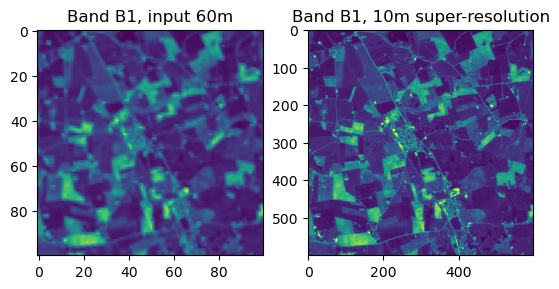

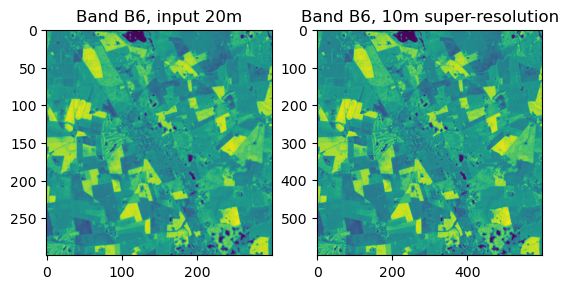

Shark Bay, no ground truth
8 4
(616, 616, 4) 5 5 36
(36, 6, 128, 128)
(36, 6, 64, 64)
(36, 4, 128, 128)
[  0  56 112 168 224 244]
[  0  56 112 168 224 244]
count= 36
Symbolic Model Created.
Predicting using file: ../models/s2_032_lr_1e-04.hdf5
2/2 [==============================] - 3s 414ms/step
(6, 600, 600)
Symbolic Model Created.
Predicting using file: ../models/s2_030_lr_1e-05.hdf5
1/1 [==============================] - 3s 3s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(2, 600, 600)


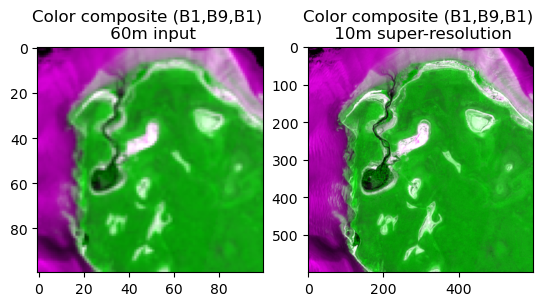

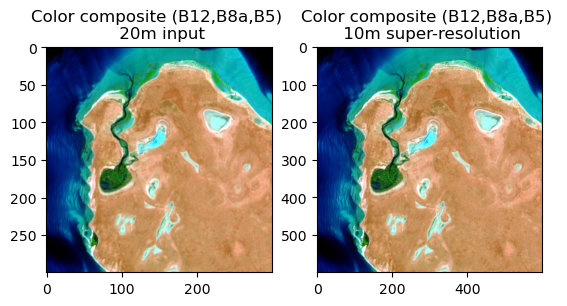

In [2]:
from __future__ import absolute_import
import h5py
import matplotlib.pyplot as plt
import numpy as np
from supres import DSen2_20, DSen2_60
import sys
sys.path.append('../')
from utils.imresize import imresize


DATA_PATH = '../data/'


def readh5(fname, im60=False, imGT=False):
    with h5py.File(DATA_PATH+fname, 'r') as f:
        d10 = f['im10'][()].transpose()
        d20 = f['im20'][()].transpose()
        if im60:
            d60 = f['im60'][()].transpose()
            if not imGT:
                return d10, d20, d60
        if imGT:
            dGT = f['imGT'][()].transpose()
            if im60:
                return d10, d20, d60, dGT
            else:
                return d10, d20, dGT
        return d10, d20


def RMSE(x1, x2):
    diff = x1.astype(np.float64)-x2.astype(np.float64)
    rms = np.sqrt(np.mean(np.power(diff, 2)))
    print('RMSE: {:.4f}'.format(rms))
    return rms


if __name__ == '__main__':

    # Siberia, same area of Fig. 8 in the paper
    print('Siberia')
    im10, im20, imGT = readh5('S2B_MSIL1C_20170725_T43WFQ.mat', imGT=True)
    SR20 = DSen2_20(im10, im20)
    # Evaluation against the ground truth on the 20m resolution bands (simulated)
    print('DSen2:')
    RMSE(SR20, imGT)
    print('Bicubic:')
    RMSE(imresize(im20, 2), imGT)

    fig = plt.figure(1)
    ax = fig.add_subplot(111)
    cax = ax.imshow(SR20[:, :, 2])
    fig.colorbar(cax)
    ax.set_title('Super-resolved band B6')

    fig = plt.figure(2)
    ax = fig.add_subplot(111)
    cax = plt.imshow(np.abs(SR20[:, :, 4]-imGT[:, :, 4]), vmin=0, vmax=200)
    fig.colorbar(cax)
    ax.set_title('Absolute differences to the GT, band B11')
    plt.show(block=False)

    #

    # South Africa, same area of Fig. 9 in the paper
    print('S. Africa')
    im10, im20, im60, imGT = readh5('S2A_MSIL1C_20171028_T34HCH.mat', im60=True, imGT=True)
    SR60 = DSen2_60(im10, im20, im60)
    # Evaluation against the ground truth on the 60m resolution bands (simulated)
    print('DSen2:')
    RMSE(SR60, imGT)
    print('Bicubic:')
    RMSE(imresize(im60, 6), imGT)

    fig = plt.figure(3)
    ax = fig.add_subplot(111)
    cax = plt.imshow(np.abs(SR60[:, :, 1]-imGT[:, :, 1]), vmin=0, vmax=200)
    fig.colorbar(cax)
    ax.set_title('Absolute differences to the GT, band B9')
    plt.show(block=False)

    #

    # New York, same area of Fig. 10 (bottom) in the paper
    # Here using the very deep variable (VDSen2)
    print('New York')
    im10, im20, imGT = readh5('S2B_MSIL1C_20170928_T18TWL.mat', im60=False, imGT=True)
    SR20 = DSen2_20(im10, im20, deep=False)
    # Evaluation against the ground truth on the 20m resolution bands (simulated)
    print('DSen2:')
    RMSE(SR20,imGT)
    print('Bicubic:')
    RMSE(imresize(im20, 2), imGT)

    #

    # Malmo, Sweden, same area of Fig. 10 (top) in the paper
    print('Malmo, no ground truth')
    im10, im20, im60 = readh5('S2A_MSIL1C_20170527_T33UUB.mat', im60=True, imGT=False)

    SR20 = DSen2_20(im10, im20)
    SR60 = DSen2_60(im10, im20, im60)

    # No ground truth available, no simulation. Comparison to the low-res input
    fig = plt.figure(4)
    ax1 = fig.add_subplot(121)
    plt.imshow(im60[:, :, 0], vmin=np.min(im60[:, :, 0]), vmax=np.max(im60[:, :, 0]))
    ax1.set_title('Band B1, input 60m')
    ax2 = fig.add_subplot(122)
    plt.imshow(SR60[:, :, 0], vmin=np.min(im60[:, :, 0]), vmax=np.max(im60[:, :, 0]))
    ax2.set_title('Band B1, 10m super-resolution')
    plt.show(block=False)

    fig = plt.figure(5)
    ax1 = fig.add_subplot(121)
    plt.imshow(im20[:, :, 1], vmin=np.min(im20[:, :, 1]), vmax=np.max(im20[:, :, 1]))
    ax1.set_title('Band B6, input 20m')
    ax2 = fig.add_subplot(122)
    plt.imshow(SR20[:, :, 1], vmin=np.min(im20[:, :, 1]), vmax=np.max(im20[:, :, 1]))
    ax2.set_title('Band B6, 10m super-resolution')
    plt.show(block=False)

    #

    # Shark bay, Australia, same area of Fig. 10 (middle) in the paper
    print('Shark Bay, no ground truth')
    im10, im20, im60 = readh5('S2B_MSIL1C_20171022_T49JGM.mat', im60=True, imGT=False)
    SR20 = DSen2_20(im10, im20)
    SR60 = DSen2_60(im10, im20, im60)

    # Stretching the image for better visualization
    for i in range(SR60.shape[2]):
        a, b = np.percentile(SR60[:, :, i], (1, 99))
        SR60[:, :, i] = np.clip(SR60[:, :, i], a, b)
        SR60[:, :, i] = (SR60[:, :, i] - a) / (b - a)
        im60[:, :, i] = np.clip(im60[:, :, i], a, b)
        im60[:, :, i] = (im60[:, :, i] - a) / (b - a)
    imSR = SR60[:, :, [0, 1, 0]]
    im60s = im60[:, :, [0, 1, 0]]

    fig = plt.figure(6)
    ax1 = fig.add_subplot(121)
    plt.imshow(im60s)
    ax1.set_title('Color composite (B1,B9,B1) \n 60m input')
    ax2 = fig.add_subplot(122)
    plt.imshow(imSR)
    ax2.set_title('Color composite (B1,B9,B1) \n 10m super-resolution')

    # Stretching the image for better visualization
    imSR = SR20[:, :, [5, 3, 0]]
    im20s = im20[:, :, [5, 3, 0]]
    for i in range(imSR.shape[2]):
        a, b = np.percentile(imSR[:, :, i], (1, 99))
        imSR[:, :, i] = np.clip(imSR[:, :, i], a, b)
        imSR[:, :, i] = (imSR[:, :, i] - a) / (b - a)
        im20s[:, :, i] = np.clip(im20s[:, :, i], a, b)
        im20s[:, :, i] = (im20s[:, :, i] - a) / (b - a)

    fig = plt.figure(7)
    ax1 = fig.add_subplot(121)
    plt.imshow(im20s)
    ax1.set_title('Color composite (B12,B8a,B5) \n 20m input')
    ax2 = fig.add_subplot(122)
    plt.imshow(imSR)
    ax2.set_title('Color composite (B12,B8a,B5) \n 10m super-resolution')

    plt.show()
